In [1]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install scipy>=1.12.0 --upgrade -v

In [3]:
!pip install psutil

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install numpy==1.24.3

Defaulting to user installation because normal site-packages is not writeable


In [5]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


2025-08-06 04:39:08.099244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754455148.108492   51538 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754455148.112996   51538 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754455148.118313   51538 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754455148.118324   51538 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754455148.118325   51538 computation_placer.cc:177] computation placer alr

GPU CONFIGURATION
GPUs available: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled
Mixed precision policy: mixed_float16

ACTIVATION FUNCTIONS COMPARISON - VORTEX DATASET

Experiment Configuration:
  Architecture: [8] hidden units
  Epochs: 40
  Batch size: 32
  Device: GPU

Generating vortex dataset...

Dataset info:
  Total samples: 2000
  Training samples: 1600
  Test samples: 400
  Class distribution: Class 0: 1015, Class 1: 985


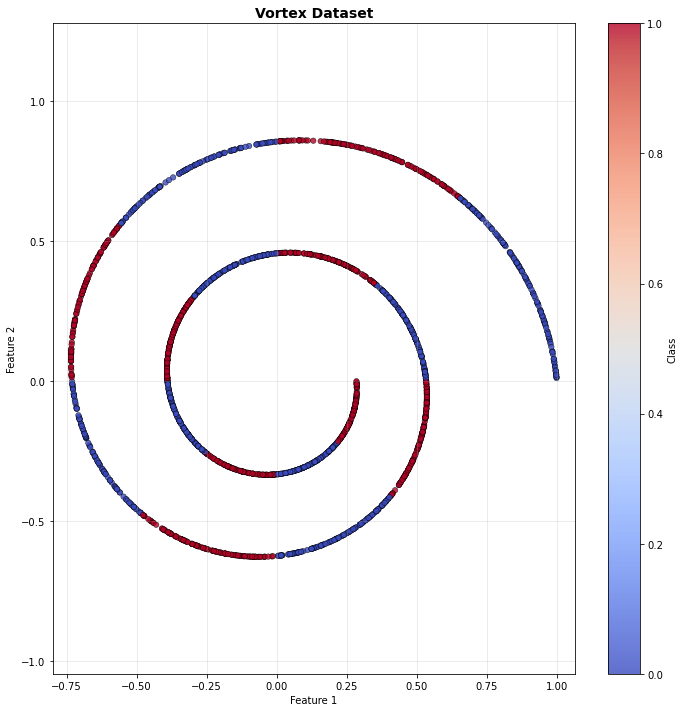


Training models with different activations...

Training with LASA activation...


I0000 00:00:1754455150.751639   51538 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94412 MB memory:  -> device: 0, name: NVIDIA GH200 480GB, pci bus id: 0000:dd:00.0, compute capability: 9.0
I0000 00:00:1754455151.584085   51538 service.cc:152] XLA service 0xbfbf584c1390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754455151.584111   51538 service.cc:160]   StreamExecutor device (0): NVIDIA GH200 480GB, Compute Capability 9.0
2025-08-06 04:39:11.595000: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754455151.709058   51538 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1754455152.202154   51538 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-08-06 04:39:12.245785: I tensorflow/core/frame

  Final Accuracy: 0.9675
  Final Loss: 0.1867

Training with RELU activation...


2025-08-06 04:39:15.895234: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Final Accuracy: 0.6300
  Final Loss: 0.5473

Training with LEAKY_RELU activation...
  Final Accuracy: 0.7900
  Final Loss: 0.4080

Training with ELU activation...


2025-08-06 04:39:20.126704: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Final Accuracy: 0.5725
  Final Loss: 0.6606

Training with SOFTPLUS activation...
  Final Accuracy: 0.5150
  Final Loss: 0.6736

Training with SWISH activation...
  Final Accuracy: 0.5200
  Final Loss: 0.6622

Training with MISH activation...


2025-08-06 04:39:28.410265: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Final Accuracy: 0.5725
  Final Loss: 0.6695

Training with GELU activation...
  Final Accuracy: 0.6775
  Final Loss: 0.6177

Training with SINE activation...
  Final Accuracy: 0.6100
  Final Loss: 0.6805

Training with SIGMOID activation...
  Final Accuracy: 0.5825
  Final Loss: 0.6811

Training with TANH activation...
  Final Accuracy: 0.7875
  Final Loss: 0.5509

FINAL RESULTS COMPARISON - VORTEX DATASET
Rank   Activation      Accuracy     Final Loss  
------------------------------------------------------------
1      LASA            0.9675       0.1867      
2      LEAKY_RELU      0.7900       0.4080      
3      TANH            0.7875       0.5509      
4      GELU            0.6775       0.6177      
5      RELU            0.6300       0.5473      
6      SINE            0.6100       0.6805      
7      SIGMOID         0.5825       0.6811      
8      ELU             0.5725       0.6606      
9      MISH            0.5725       0.6695      
10     SWISH           0.5200       0

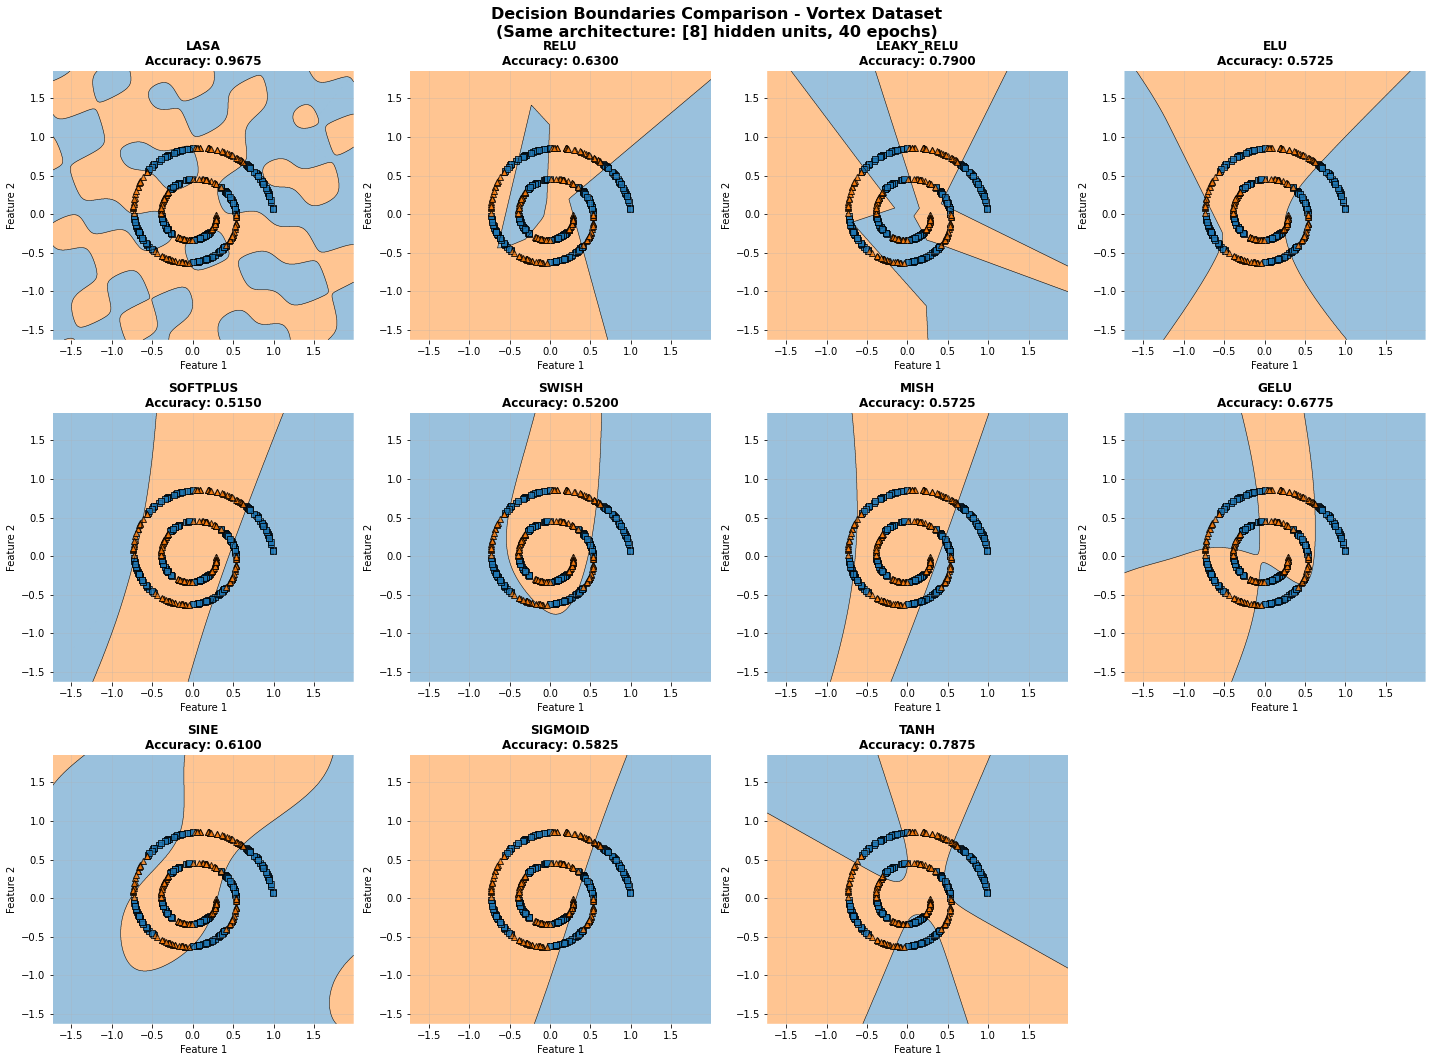

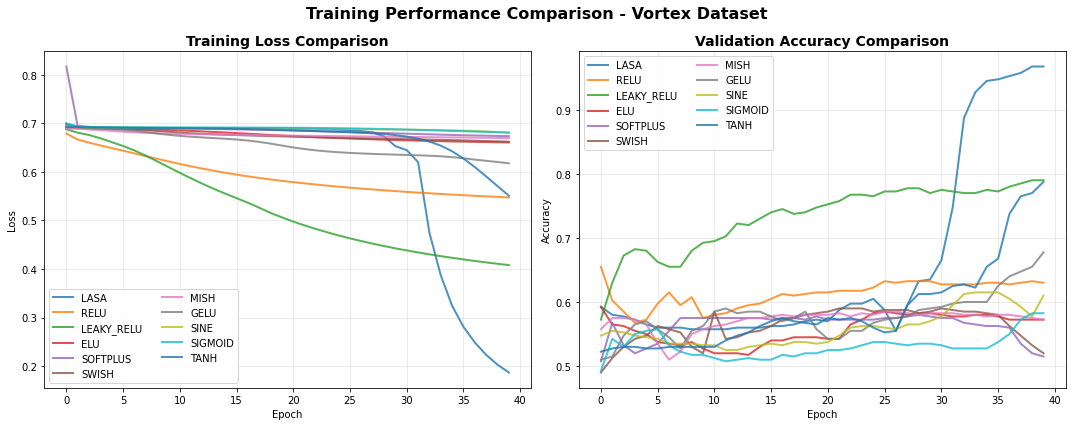

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU Configuration
# ============================================================================

# Check GPU availability
print("="*60)
print("GPU CONFIGURATION")
print("="*60)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
   print(f"GPUs available: {len(gpus)}")
   for gpu in gpus:
       print(f"  - {gpu}")
   try:
       # Enable memory growth to avoid allocating all GPU memory at once
       for gpu in gpus:
           tf.config.experimental.set_memory_growth(gpu, True)
       print("GPU memory growth enabled")
   except RuntimeError as e:
       print(e)
else:
   print("No GPUs available, using CPU")

# Set mixed precision policy for faster training on GPU
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)
print(f"Mixed precision policy: {policy.name}")
print("="*60 + "\n")

# ============================================================================
# Dataset Generation - VORTEX
# ============================================================================

def generate_vortex(n_samples=1000):
   """Generate vortex dataset with spiral pattern"""
   t = np.random.uniform(0, 4*np.pi, n_samples)
   r = np.exp(-0.1 * t)
   X = np.column_stack((r * np.cos(t), r * np.sin(t)))
   y = np.where(np.sin(4*t) > 0, 0, 1)
   return X, y

# ============================================================================
# LASA Component
# ============================================================================

class LASAActivation(tf.keras.layers.Layer):
   """Layer-wise Adaptive Sine Activation (LASA) layer"""
   
   def __init__(self, initial_frequency=1.6, **kwargs):
       super().__init__(**kwargs)
       self.initial_frequency = initial_frequency
   
   def build(self, input_shape):
       self.tau = self.add_weight(
           shape=(), 
           initializer=tf.keras.initializers.Constant(self.initial_frequency),
           trainable=True, 
           name='tau',
           dtype=tf.float32  # Keep tau in float32 for stability
       )
   
   def call(self, inputs):
       # Cast tau to match input dtype for mixed precision
       tau = tf.cast(self.tau, inputs.dtype)
       return tf.math.sin(tau * inputs)


# ============================================================================
# Custom Activation Layers
# ============================================================================

class MishActivation(tf.keras.layers.Layer):
   """Mish activation: x * tanh(softplus(x))"""
   def call(self, inputs):
       return inputs * tf.math.tanh(tf.math.softplus(inputs))


class SwishActivation(tf.keras.layers.Layer):
   """Swish activation: x * sigmoid(x)"""
   def call(self, inputs):
       return inputs * tf.nn.sigmoid(inputs)


# ============================================================================
# Universal Model Builder
# ============================================================================

def create_model(activation_type, hidden_units=[8], initial_frequency=1.6):
   """Create a model with specified activation function"""
   
   # Ensure model is created on GPU
   with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
       model = tf.keras.Sequential()
       model.add(tf.keras.layers.Input(shape=(2,)))
       
       for i, units in enumerate(hidden_units):
           # Add dense layer
           model.add(tf.keras.layers.Dense(units, name=f'dense_{i}'))
           
           # Add activation based on type
           if activation_type == 'lasa':
               model.add(LASAActivation(initial_frequency=initial_frequency, name=f'lasa_{i}'))
           elif activation_type == 'relu':
               model.add(tf.keras.layers.ReLU(name=f'relu_{i}'))
           elif activation_type == 'leaky_relu':
               model.add(tf.keras.layers.LeakyReLU(alpha=0.01, name=f'leaky_relu_{i}'))
           elif activation_type == 'elu':
               model.add(tf.keras.layers.ELU(alpha=1.0, name=f'elu_{i}'))
           elif activation_type == 'softplus':
               model.add(tf.keras.layers.Activation('softplus', name=f'softplus_{i}'))
           elif activation_type == 'swish':
               model.add(SwishActivation(name=f'swish_{i}'))
           elif activation_type == 'mish':
               model.add(MishActivation(name=f'mish_{i}'))
           elif activation_type == 'gelu':
               model.add(tf.keras.layers.Activation('gelu', name=f'gelu_{i}'))
           elif activation_type == 'sine':
               model.add(tf.keras.layers.Activation(tf.math.sin, name=f'sine_{i}'))
           elif activation_type == 'sigmoid':
               model.add(tf.keras.layers.Activation('sigmoid', name=f'sigmoid_{i}'))
           elif activation_type == 'tanh':
               model.add(tf.keras.layers.Activation('tanh', name=f'tanh_{i}'))
       
       # Output layer with float32 for stability
       model.add(tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32', name='output'))
   
   return model


# ============================================================================
# Universal Trainer with GPU optimization
# ============================================================================

class UniversalTrainer:
   """Trainer that works for all activation types"""
   
   def __init__(self, model, activation_type, lr_main=0.001, lr_tau=0.01):
       self.model = model
       self.activation_type = activation_type
       self.loss_fn = tf.keras.losses.BinaryCrossentropy()
       
       # For LASA, use separate optimizers
       if activation_type == 'lasa':
           self.optimizer_main = tf.keras.optimizers.Adam(learning_rate=lr_main)
           self.optimizer_tau = tf.keras.optimizers.Adam(learning_rate=lr_tau)
       else:
           self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_main)
   
   @tf.function(jit_compile=True)  # Enable XLA compilation for GPU
   def train_step_lasa(self, x_batch, y_batch):
       """Training step for LASA with separate tau optimization"""
       with tf.GradientTape() as tape:
           predictions = self.model(x_batch, training=True)
           y_batch = tf.reshape(y_batch, (-1, 1))
           loss = self.loss_fn(y_batch, predictions)
       
       grads = tape.gradient(loss, self.model.trainable_variables)
       
       tau_vars = [v for v in self.model.trainable_variables if 'tau' in v.name]
       other_vars = [v for v in self.model.trainable_variables if 'tau' not in v.name]
       
       tau_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' in v.name]
       other_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' not in v.name]
       
       self.optimizer_tau.apply_gradients(zip(tau_grads, tau_vars))
       self.optimizer_main.apply_gradients(zip(other_grads, other_vars))
       
       return loss
   
   @tf.function(jit_compile=True)  # Enable XLA compilation for GPU
   def train_step_regular(self, x_batch, y_batch):
       """Training step for regular activations"""
       with tf.GradientTape() as tape:
           predictions = self.model(x_batch, training=True)
           y_batch = tf.reshape(y_batch, (-1, 1))
           loss = self.loss_fn(y_batch, predictions)
       
       grads = tape.gradient(loss, self.model.trainable_variables)
       self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
       
       return loss
   
   def train(self, X_train, y_train, X_test, y_test, epochs=40, batch_size=32, verbose=False):
       """Train the model"""
       # Convert to TensorFlow tensors and place on GPU
       X_train = tf.constant(X_train, dtype=tf.float32)
       y_train = tf.constant(y_train, dtype=tf.float32)
       X_test = tf.constant(X_test, dtype=tf.float32)
       y_test_np = y_test  # Keep numpy version for accuracy calculation
       
       # Create TensorFlow dataset for efficient GPU feeding
       train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
       train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
       
       history = {'loss': [], 'val_accuracy': []}
       
       for epoch in range(epochs):
           total_loss = 0.0
           num_batches = 0
           
           for x_batch, y_batch in train_dataset:
               if self.activation_type == 'lasa':
                   batch_loss = self.train_step_lasa(x_batch, y_batch)
               else:
                   batch_loss = self.train_step_regular(x_batch, y_batch)
               
               total_loss += batch_loss.numpy()
               num_batches += 1
           
           avg_loss = total_loss / num_batches
           
           # Evaluation
           predictions = self.model(X_test)
           y_pred = (predictions > 0.5).numpy().astype(int).flatten()
           accuracy = np.mean(y_pred == y_test_np)
           
           history['loss'].append(avg_loss)
           history['val_accuracy'].append(accuracy)
           
           if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
               print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.4f}")
       
       return history


# ============================================================================
# Visualization Functions
# ============================================================================

def plot_dataset(X, y, title="Vortex Dataset"):
   """Plot the dataset"""
   plt.figure(figsize=(10, 10))
   scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                       edgecolors='black', linewidth=0.5, alpha=0.8, s=30)
   plt.colorbar(scatter, label='Class')
   plt.title(title, fontsize=14, fontweight='bold')
   plt.xlabel('Feature 1')
   plt.ylabel('Feature 2')
   plt.grid(True, alpha=0.3)
   plt.axis('equal')
   plt.tight_layout()
   plt.show()


def plot_all_decision_boundaries(models, results, X_test, y_test):
   """Plot decision boundaries for all activation functions"""
   
   # Create wrapper for mlxtend
   class ModelWrapper:
       def __init__(self, keras_model):
           self.model = keras_model
       
       def predict(self, X):
           # Ensure prediction happens on GPU
           X_tensor = tf.constant(X, dtype=tf.float32)
           with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
               predictions = self.model(X_tensor)
           return (predictions.numpy() > 0.5).astype(int).flatten()
   
   # Create subplots
   fig, axes = plt.subplots(3, 4, figsize=(20, 15))
   axes = axes.flatten()
   
   activation_names = list(models.keys())
   
   for idx, activation in enumerate(activation_names):
       ax = axes[idx]
       model = models[activation]
       accuracy = results[activation]['accuracy']
       
       # Plot decision regions
       wrapper = ModelWrapper(model)
       plot_decision_regions(X=X_test, y=y_test, clf=wrapper, 
                           ax=ax, legend=0)
       
       # Set title with accuracy
       title = f"{activation.upper()}\nAccuracy: {accuracy:.4f}"
       ax.set_title(title, fontsize=12, fontweight='bold')
       ax.set_xlabel('Feature 1', fontsize=10)
       ax.set_ylabel('Feature 2', fontsize=10)
       ax.grid(True, alpha=0.3)
   
   # Remove extra subplot if any
   if len(activation_names) < len(axes):
       for idx in range(len(activation_names), len(axes)):
           fig.delaxes(axes[idx])
   
   plt.suptitle('Decision Boundaries Comparison - Vortex Dataset\n(Same architecture: [8] hidden units, 40 epochs)', 
                fontsize=16, fontweight='bold')
   plt.tight_layout()
   plt.show()


def plot_training_curves_comparison(results):
   """Plot training curves for all activations"""
   
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
   
   for activation, data in results.items():
       # Plot loss
       ax1.plot(data['history']['loss'], label=activation.upper(), linewidth=2, alpha=0.8)
       
       # Plot accuracy
       ax2.plot(data['history']['val_accuracy'], label=activation.upper(), linewidth=2, alpha=0.8)
   
   ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
   ax1.set_xlabel('Epoch')
   ax1.set_ylabel('Loss')
   ax1.legend(loc='best', ncol=2)
   ax1.grid(True, alpha=0.3)
   
   ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
   ax2.set_xlabel('Epoch')
   ax2.set_ylabel('Accuracy')
   ax2.legend(loc='best', ncol=2)
   ax2.grid(True, alpha=0.3)
   
   plt.suptitle('Training Performance Comparison - Vortex Dataset', fontsize=16, fontweight='bold')
   plt.tight_layout()
   plt.show()


def print_comparison_table(results):
   """Print a formatted comparison table"""
   
   print("\n" + "="*60)
   print("FINAL RESULTS COMPARISON - VORTEX DATASET")
   print("="*60)
   print(f"{'Rank':<6} {'Activation':<15} {'Accuracy':<12} {'Final Loss':<12}")
   print("-"*60)
   
   # Sort by accuracy
   sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
   
   for rank, (activation, data) in enumerate(sorted_results, 1):
       print(f"{rank:<6} {activation.upper():<15} {data['accuracy']:<12.4f} {data['final_loss']:<12.4f}")
   
   print("="*60)


# ============================================================================
# Comparison Experiment
# ============================================================================

def run_vortex_comparison(hidden_units=[8], initial_frequency=1.6,
                        n_samples=2000, test_size=0.2,
                        epochs=40, batch_size=32, random_state=42):
   """Compare all activation functions on vortex dataset"""
   
   # Define all activation types to compare
   activation_types = [
       'lasa', 'relu', 'leaky_relu', 'elu', 'softplus', 
       'swish', 'mish', 'gelu', 'sine', 'sigmoid', 'tanh'
   ]
   
   # Generate dataset
   print("="*60)
   print("ACTIVATION FUNCTIONS COMPARISON - VORTEX DATASET")
   print("="*60)
   print("\nExperiment Configuration:")
   print(f"  Architecture: {hidden_units} hidden units")
   print(f"  Epochs: {epochs}")
   print(f"  Batch size: {batch_size}")
   print(f"  Device: {'GPU' if tf.config.list_physical_devices('GPU') else 'CPU'}")
   
   print("\nGenerating vortex dataset...")
   X_vortex, y_vortex = generate_vortex(n_samples=n_samples)
   X_vortex = X_vortex.astype(np.float32)  # Ensure float32 for GPU
   y_vortex = y_vortex.astype(np.int32)  # Keep as int for plotting
   
   X_train, X_test, y_train, y_test = train_test_split(
       X_vortex, y_vortex, test_size=test_size, random_state=random_state, stratify=y_vortex
   )
   
   print(f"\nDataset info:")
   print(f"  Total samples: {n_samples}")
   print(f"  Training samples: {len(X_train)}")
   print(f"  Test samples: {len(X_test)}")
   print(f"  Class distribution: Class 0: {np.sum(y_vortex==0)}, Class 1: {np.sum(y_vortex==1)}")
   
   # Plot the dataset
   plot_dataset(X_vortex, y_vortex)
   
   results = {}
   models = {}
   
   print("\nTraining models with different activations...")
   print("="*60)
   
   for activation in activation_types:
       print(f"\nTraining with {activation.upper()} activation...")
       
       # Clear session to free GPU memory between models
       tf.keras.backend.clear_session()
       
       # Create model
       model = create_model(activation, hidden_units, initial_frequency)
       
       # Train model - convert y to float for training
       trainer = UniversalTrainer(model, activation, lr_main=0.01, lr_tau=0.01)
       history = trainer.train(X_train, y_train.astype(np.float32), X_test, y_test, 
                             epochs=epochs, batch_size=batch_size, verbose=False)
       
       # Final evaluation on GPU
       with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
           X_test_tensor = tf.constant(X_test, dtype=tf.float32)
           predictions = model(X_test_tensor)
       
       y_pred = (predictions.numpy() > 0.5).astype(int).flatten()
       final_accuracy = np.mean(y_pred == y_test)
       
       # Store results
       results[activation] = {
           'accuracy': final_accuracy,
           'history': history,
           'final_loss': history['loss'][-1]
       }
       models[activation] = model
       
       print(f"  Final Accuracy: {final_accuracy:.4f}")
       print(f"  Final Loss: {history['loss'][-1]:.4f}")
   
   return models, results, X_vortex, y_vortex, X_test, y_test


# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
   # Run the comparison experiment
   models, results, X, y, X_test, y_test = run_vortex_comparison(
       hidden_units=[8],
       initial_frequency=1.6,
       epochs=40,
       batch_size=32,
       n_samples=2000
   )
   
   # Print comparison table
   print_comparison_table(results)
   
   # Plot all decision boundaries
   plot_all_decision_boundaries(models, results, X_test, y_test)
   
   # Plot training curves
   plot_training_curves_comparison(results)